In [1]:
# import standard python libraries
import matplotlib as mpl
%matplotlib inline
mpl.rcParams['figure.dpi'] = 96
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os, subprocess
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# import libraries for biological data analysis
from coolpuppy import coolpup
from coolpuppy.lib import numutils
from coolpuppy.lib.puputils import divide_pups
from coolpuppy import plotpup
import cooler
import bioframe
import cooltools
from cooltools import expected_cis, expected_trans
from cooltools.lib import plotting

%cd /home/varshini/uc_analyses/
import utils
%cd /home/varshini/LoopCall_Analysis_Scripts

from functools import reduce

plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

from itertools import product

/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


In [2]:
conds = ['AAVS1','STAG2','STAG1','NIPBL']

reps = ['C3', 'C2']
#reps=['C2']
guides = {'AAVS1':'G1', 'STAG1':'G1', 'STAG2':'G2', 'NIPBL':'G1'}

uc_path = '/mnt/md0/varshini/Analysis/sankaran_cohesin/mcools_per_rep'
uc_expected_path = '/mnt/md0/varshini/Analysis/Blood/microc_expected'

resolution = 10000
uc_filenames = [os.path.join(uc_path, f'{cond}_{rep}_{guides[cond]}_all.250.mcool') for cond, rep in product(conds, reps)]
clrs = [utils.get_clr(clr_name, resolution) for clr_name in uc_filenames]

#[cooler.fileops.list_coolers(c) for c in phase_clr_names]
exps = [os.path.join(uc_expected_path, f"P_s_{cond}_{rep}_{guides[cond]}_{resolution}bp_hg38arms.tsv") for cond, rep in product(conds, reps)]

for expfile, clr in zip(exps, clrs):
    # Use bioframe to fetch the genomic features from the UCSC.
    hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
    hg38_cens = bioframe.fetch_centromeres('hg38')
    # create a view with chromosome arms using chromosome sizes and definition of centromeres
    hg38_arms = bioframe.make_chromarms(hg38_chromsizes,  hg38_cens)

    # select only those chromosomes available in cooler
    hg38_arms = hg38_arms[hg38_arms.chrom.isin(clr.chromnames)].reset_index(drop=True)
    hg38_arms = hg38_arms[~hg38_arms["chrom"].isin(['chrY','chrM'])]
    if not (os.path.isfile(expfile)):
            cvd = cooltools.expected_cis(clr=clr, smooth=True, view_df=hg38_arms, aggregate_smoothed=True, nproc=16)
            #print(cvd)
            cvd = cvd[~cvd["region1"].isin(['chrY_p', 'chrM_p'])]
            cvd.to_csv(expfile, index=False, sep='\t')

In [3]:
phases = [f"{cond}_{rep}" for cond, rep in product(conds, reps)]

In [4]:
phases

['AAVS1_C3',
 'AAVS1_C2',
 'STAG2_C3',
 'STAG2_C2',
 'STAG1_C3',
 'STAG1_C2',
 'NIPBL_C3',
 'NIPBL_C2']

In [10]:
 # pileups
datapath = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/'
subdir = 'nipbl_erythroid_tf_acrs_all_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed'
subdir = 'nipbl_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed'
savedir = "/mnt/md0/varshini/Analysis/Blood/figs_v2/figure5"
track = pd.read_csv(os.path.join(datapath, subdir), sep='\t')
track['quant_diff'] = track['quant_diff'].clip(upper=3)
track['quant'] = track['quant'].clip(upper=3)

track = track[(track['quant_diff']==2) |  (track['quant_diff']==3)]

INFO:coolpuppy:('chr4_p', 'chr4_p'): 86
INFO:coolpuppy:('chr5_p', 'chr5_p'): 61
INFO:coolpuppy:('chr8_p', 'chr8_p'): 91
INFO:coolpuppy:('chr6_p', 'chr6_p'): 220
INFO:coolpuppy:('chr7_p', 'chr7_p'): 146
INFO:coolpuppy:('chr2_p', 'chr2_p'): 270
INFO:coolpuppy:('chr3_p', 'chr3_p'): 213
INFO:coolpuppy:('chr1_p', 'chr1_p'): 383
INFO:coolpuppy:('chr8_q', 'chr8_q'): 230
INFO:coolpuppy:('chr7_q', 'chr7_q'): 227
INFO:coolpuppy:('chr5_q', 'chr5_q'): 311
INFO:coolpuppy:('chr6_q', 'chr6_q'): 212
INFO:coolpuppy:('chr9_p', 'chr9_p'): 78
INFO:coolpuppy:('chr4_q', 'chr4_q'): 241
INFO:coolpuppy:('chr10_p', 'chr10_p'): 106
INFO:coolpuppy:('chr3_q', 'chr3_q'): 309
INFO:coolpuppy:('chr12_p', 'chr12_p'): 106
INFO:coolpuppy:('chr11_p', 'chr11_p'): 133
INFO:coolpuppy:('chr9_q', 'chr9_q'): 240
INFO:coolpuppy:('chr1_q', 'chr1_q'): 341
INFO:coolpuppy:('chr13_q', 'chr13_q'): 198
INFO:coolpuppy:('chr2_q', 'chr2_q'): 343
INFO:coolpuppy:('chr14_q', 'chr14_q'): 227
INFO:coolpuppy:('chr10_q', 'chr10_q'): 214
INFO:coo

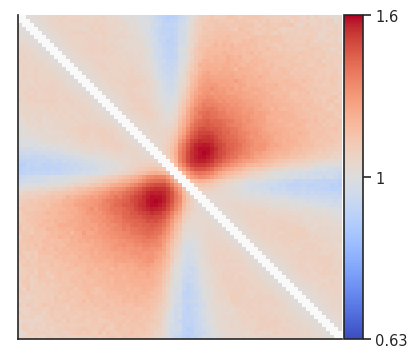

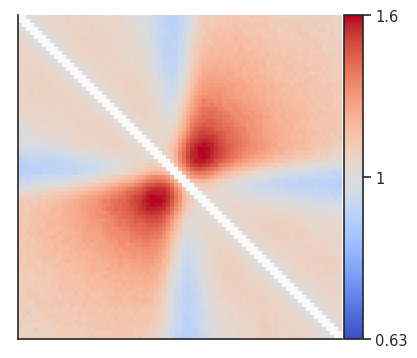

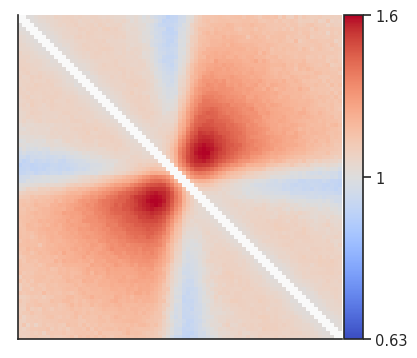

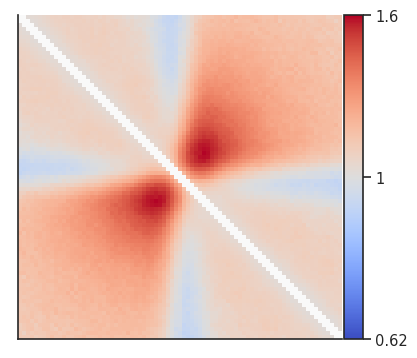

In [11]:
pup_mats_all = [None]*4
for quant in [0]:
    track_sub = track.copy()
    track_sub['chrom'] = track_sub['chr']
    track_sub['start'] = track_sub['coord']-100
    track_sub['end'] = track_sub['coord']+100
    pup_mats_all[quant] = {}
    
    for p in [0, 1, 2, 3]:   
        clr = clrs[p]
        
        phase_name = phases[p]
        
        exp0 =  pd.read_csv(exps[p], sep='\t')
    
        pup = coolpup.pileup(clr, track_sub, features_format='bed', local=True, view_df=hg38_arms,
                                        flank=400_000, expected_df = exp0, min_diag=0, nproc=8)
        fg = plotpup.plot(pup,
                             score=False, cmap='coolwarm', scale='log', sym=True,
                             height=5, vmax=1.6)

        fg.savefig(os.path.join(savedir, f"{p}_pileup_mms.svg"))
        pup_mats_all[quant][phase_name] = pup
        

In [18]:
phases

['AAVS1_C3', 'AAVS1_C2', 'STAG2_C3', 'STAG2_C2']

In [19]:
conds

['AAVS1', 'STAG2', 'STAG1', 'NIPBL']

6
6
6
6


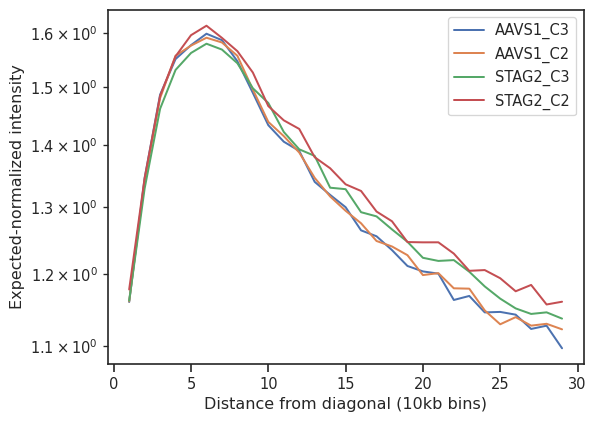

In [24]:
# ortho stripe
pup_mats_quant = pup_mats_all[0]
f, ax = plt.subplots()
savedir = "/mnt/md0/varshini/Analysis/Blood/figs_v2/figure5"
for i, phase in enumerate(phases):
    snip1 = pup_mats_quant[phase]
    snip = snip1['data'][0]
    n = snip.shape[0]

    mid = n // 2

    # compute valid range lengths
    steps_up = mid + 1
    steps_right = n - mid
    L = min(steps_up, steps_right)

    # equal-length indices for the 45 anti-diagonal (upper half)
    rows = np.arange(mid, mid - L, -1)
    cols = np.arange(mid, mid + L)

    ortho_stripe = snip[rows, cols]
    max_ortho_ind = np.nanargmax(ortho_stripe)
    if 'STAG2' in phase or 'AAVS1' in phase:
        ax.plot(ortho_stripe[:30], label=phases[i])
        #ax.scatter(max_ortho_ind, 1)
    print(max_ortho_ind)
plt.legend()
plt.yscale('log')
plt.xlabel('Distance from diagonal (10kb bins)')
plt.ylabel('Expected-normalized intensity')
plt.savefig(os.path.join(savedir, "stag2_ortho_stripe_all.svg"))
plt.show()

In [16]:
np.max(ortho_stripe[:30])

nan